<a href="https://colab.research.google.com/github/ArshanBhanage/258-Assignment_3/blob/main/colab_e_tensorflow_variants_3layer_einsum_required.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab (e) — TensorFlow variants (same 3-layer nonlinear regression)
This notebook contains **four variants** of the same model:

1. **(i) TensorFlow scratch** (no Keras layers/models) using `tf.Variable` + `tf.GradientTape`  
   ✅ **Uses `tf.einsum`** for all linear algebra (required).
2. **(ii) TensorFlow with built-in layers** using `tf.keras.Sequential` + `Dense`
3. **(iii) TensorFlow Functional API** using `tf.keras.Model(inputs, outputs)`
4. **(iv) TensorFlow high-level API** using `compile()` + `fit()` (can overlap with ii/iii but shown explicitly)

Common requirements covered:
- Synthetic data from **3-variable nonlinear equation**
- **3-layer network**: `3 → H1 → H2 → 1`
- Nonlinear activations
- Loss curves + test evaluation + true-vs-predicted plot
- “4D plot”: PCA to 3D + color = y


## 0. Setup

In [1]:
# !pip -q install tensorflow numpy matplotlib scikit-learn pandas

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


## 1. Generate synthetic nonlinear regression data (3 variables)

In [2]:
def nonlinear_equation(x1, x2, x3):
    return (
        2.0 * np.sin(x1)
        + 0.5 * (x2 ** 2)
        - 3.0 * np.exp(-x3)
        + 0.3 * x1 * x2
        - 0.2 * x2 * x3
    )

N = 6000
x1 = np.random.uniform(-3.0, 3.0, size=(N, 1))
x2 = np.random.uniform(-2.0, 2.0, size=(N, 1))
x3 = np.random.uniform(0.0, 4.0, size=(N, 1))

X = np.concatenate([x1, x2, x3], axis=1)
noise = np.random.normal(0.0, 0.2, size=(N, 1))
y = nonlinear_equation(x1, x2, x3).reshape(-1, 1) + noise

print("X shape:", X.shape, "y shape:", y.shape)


X shape: (6000, 3) y shape: (6000, 1)


## 2. Quick visualization ("4D" plot via PCA + color = y)

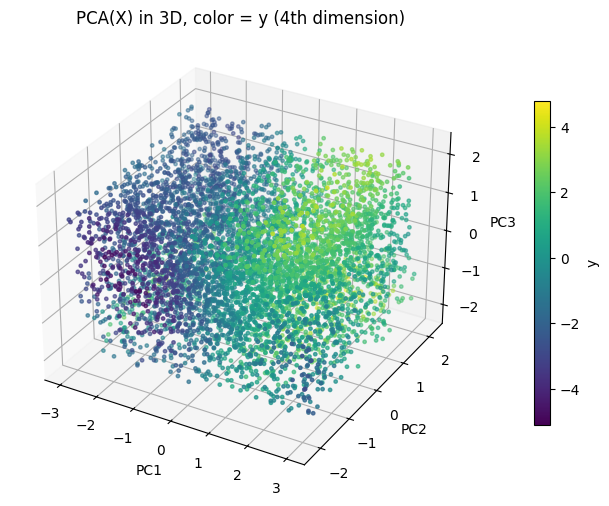

In [3]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y[:, 0], s=6)
ax.set_title("PCA(X) in 3D, color = y (4th dimension)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="y")
plt.show()


## 3. Train/Val/Test split + standardization

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

print("Train:", X_train_s.shape, y_train_s.shape)
print("Val  :", X_val_s.shape, y_val_s.shape)
print("Test :", X_test_s.shape, y_test_s.shape)

# Convert to tf tensors
X_train_t = tf.convert_to_tensor(X_train_s, dtype=tf.float32)
y_train_t = tf.convert_to_tensor(y_train_s, dtype=tf.float32)

X_val_t = tf.convert_to_tensor(X_val_s, dtype=tf.float32)
y_val_t = tf.convert_to_tensor(y_val_s, dtype=tf.float32)

X_test_t = tf.convert_to_tensor(X_test_s, dtype=tf.float32)
y_test_t = tf.convert_to_tensor(y_test_s, dtype=tf.float32)


Train: (4200, 3) (4200, 1)
Val  : (900, 3) (900, 1)
Test : (900, 3) (900, 1)


## Variant (i): TensorFlow scratch (NO Keras layers/models) — **tf.einsum only**

Epoch    1 | train MSE: 1.143820 | val MSE: 0.996753
Epoch   25 | train MSE: 0.402385 | val MSE: 0.425592
Epoch   50 | train MSE: 0.388779 | val MSE: 0.411515
Epoch   75 | train MSE: 0.369537 | val MSE: 0.393254
Epoch  100 | train MSE: 0.344545 | val MSE: 0.369020
Epoch  125 | train MSE: 0.312277 | val MSE: 0.337773
Epoch  150 | train MSE: 0.276621 | val MSE: 0.301520
Epoch  175 | train MSE: 0.238758 | val MSE: 0.262711
Epoch  200 | train MSE: 0.202630 | val MSE: 0.224194
Epoch  225 | train MSE: 0.169766 | val MSE: 0.187891
Epoch  250 | train MSE: 0.140848 | val MSE: 0.155769


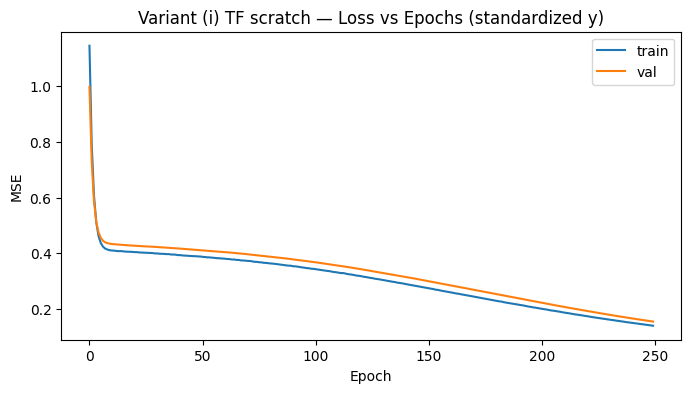

In [5]:
# --- Hyperparameters ---
d_in, h1, h2, d_out = 3, 64, 32, 1
lr = 1e-3
epochs = 250
batch_size = 128

# Xavier init
def xavier(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return tf.random.uniform((in_dim, out_dim), minval=-limit, maxval=limit, dtype=tf.float32)

# Parameters as tf.Variable
W1 = tf.Variable(xavier(d_in, h1))
b1 = tf.Variable(tf.zeros((h1,), dtype=tf.float32))

W2 = tf.Variable(xavier(h1, h2))
b2 = tf.Variable(tf.zeros((h2,), dtype=tf.float32))

W3 = tf.Variable(xavier(h2, d_out))
b3 = tf.Variable(tf.zeros((d_out,), dtype=tf.float32))

params = [W1, b1, W2, b2, W3, b3]

def forward_einsum(Xb):
    # z1 = X W1 + b1   (ONLY tf.einsum)
    z1 = tf.einsum('bi,io->bo', Xb, W1) + b1
    a1 = tf.math.tanh(z1)

    # z2 = a1 W2 + b2
    z2 = tf.einsum('bi,io->bo', a1, W2) + b2
    a2 = tf.math.tanh(z2)

    # yhat = a2 W3 + b3 (linear)
    yhat = tf.einsum('bi,io->bo', a2, W3) + b3
    return yhat

def mse_tf(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))

# Dataset pipeline
train_ds = tf.data.Dataset.from_tensor_slices((X_train_t, y_train_t)).shuffle(4096, seed=42).batch(batch_size)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val_t, y_val_t)).batch(batch_size)

train_losses_i, val_losses_i = [], []

for epoch in range(1, epochs + 1):
    # ---- Train ----
    epoch_train = tf.keras.metrics.Mean()
    for Xb, yb in train_ds:
        with tf.GradientTape() as tape:
            yhat = forward_einsum(Xb)
            loss = mse_tf(yb, yhat)
        grads = tape.gradient(loss, params)

        # Manual SGD update
        for p, g in zip(params, grads):
            p.assign_sub(lr * g)

        epoch_train.update_state(loss)

    # ---- Validate ----
    epoch_val = tf.keras.metrics.Mean()
    for Xb, yb in val_ds:
        yhat = forward_einsum(Xb)
        loss = mse_tf(yb, yhat)
        epoch_val.update_state(loss)

    train_losses_i.append(float(epoch_train.result().numpy()))
    val_losses_i.append(float(epoch_val.result().numpy()))

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {train_losses_i[-1]:.6f} | val MSE: {val_losses_i[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses_i, label="train")
plt.plot(val_losses_i, label="val")
plt.title("Variant (i) TF scratch — Loss vs Epochs (standardized y)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## Evaluate Variant (i) on test set (original y scale)

Variant (i) TEST MSE (original y): 0.502477625321202


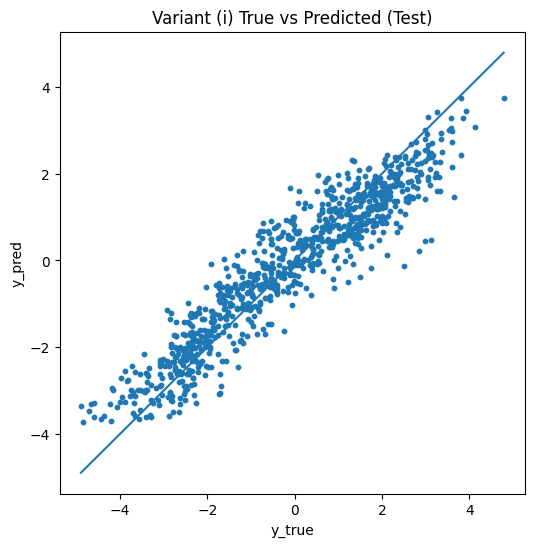

In [6]:
# Predict standardized
y_test_hat_s = forward_einsum(X_test_t).numpy()

# Inverse-transform back to original scale
y_test_hat = y_scaler.inverse_transform(y_test_hat_s)
y_test_true = y_test

test_mse_i = float(np.mean((y_test_hat - y_test_true) ** 2))
print("Variant (i) TEST MSE (original y):", test_mse_i)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true[:, 0], y_test_hat[:, 0], s=10)
plt.title("Variant (i) True vs Predicted (Test)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
minv = min(y_test_true.min(), y_test_hat.min())
maxv = max(y_test_true.max(), y_test_hat.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()


## Variant (ii): TensorFlow with built-in layers (Sequential + Dense)

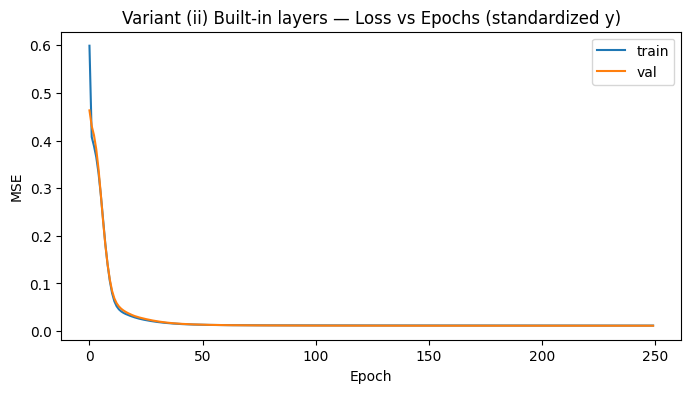

In [7]:
model_ii = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)  # linear output
])

model_ii.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history_ii = model_ii.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=250,
    batch_size=128,
    verbose=0
)

plt.figure(figsize=(8, 4))
plt.plot(history_ii.history["loss"], label="train")
plt.plot(history_ii.history["val_loss"], label="val")
plt.title("Variant (ii) Built-in layers — Loss vs Epochs (standardized y)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## Evaluate Variant (ii) on test set (original y scale)

Variant (ii) TEST MSE (original y): 0.04181133716010468


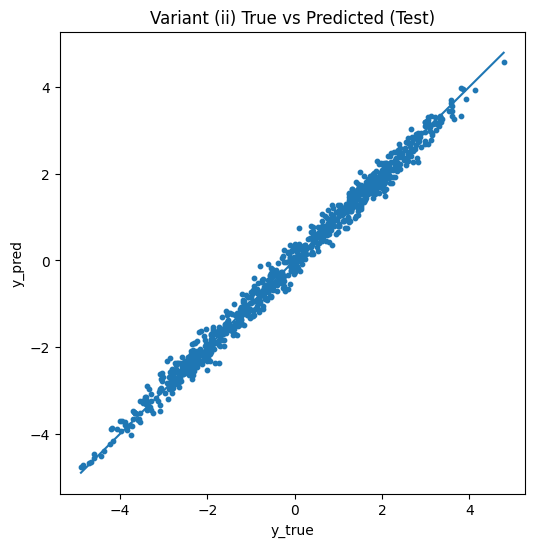

In [8]:
y_test_hat_s_ii = model_ii.predict(X_test_s, verbose=0)
y_test_hat_ii = y_scaler.inverse_transform(y_test_hat_s_ii)

test_mse_ii = float(np.mean((y_test_hat_ii - y_test) ** 2))
print("Variant (ii) TEST MSE (original y):", test_mse_ii)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[:, 0], y_test_hat_ii[:, 0], s=10)
plt.title("Variant (ii) True vs Predicted (Test)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
minv = min(y_test.min(), y_test_hat_ii.min())
maxv = max(y_test.max(), y_test_hat_ii.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()


## Variant (iii): TensorFlow Functional API

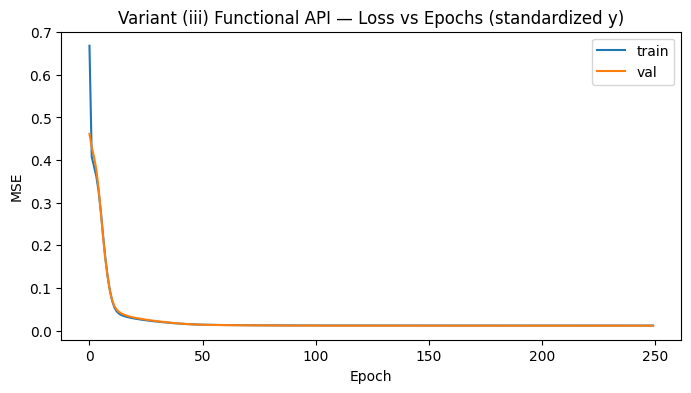

In [9]:
inputs = tf.keras.Input(shape=(3,))
x = tf.keras.layers.Dense(64, activation="tanh")(inputs)
x = tf.keras.layers.Dense(32, activation="tanh")(x)
outputs = tf.keras.layers.Dense(1)(x)

model_iii = tf.keras.Model(inputs, outputs)
model_iii.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history_iii = model_iii.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=250,
    batch_size=128,
    verbose=0
)

plt.figure(figsize=(8, 4))
plt.plot(history_iii.history["loss"], label="train")
plt.plot(history_iii.history["val_loss"], label="val")
plt.title("Variant (iii) Functional API — Loss vs Epochs (standardized y)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## Evaluate Variant (iii) on test set (original y scale)

Variant (iii) TEST MSE (original y): 0.04143856735797147


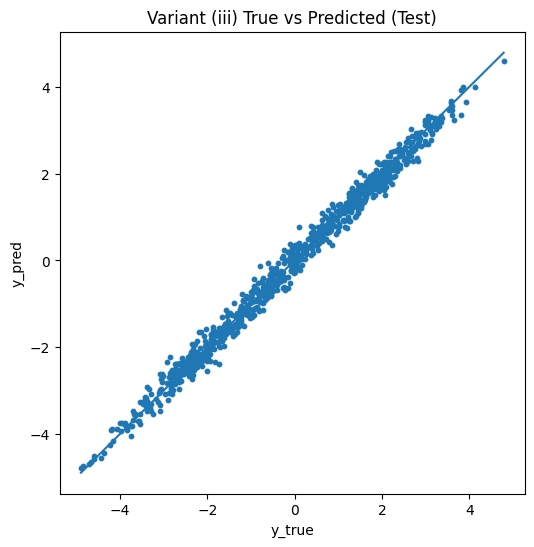

In [10]:
y_test_hat_s_iii = model_iii.predict(X_test_s, verbose=0)
y_test_hat_iii = y_scaler.inverse_transform(y_test_hat_s_iii)

test_mse_iii = float(np.mean((y_test_hat_iii - y_test) ** 2))
print("Variant (iii) TEST MSE (original y):", test_mse_iii)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[:, 0], y_test_hat_iii[:, 0], s=10)
plt.title("Variant (iii) True vs Predicted (Test)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
minv = min(y_test.min(), y_test_hat_iii.min())
maxv = max(y_test.max(), y_test_hat_iii.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()


## Variant (iv): High-level API (explicit `compile` + `fit` + callbacks)

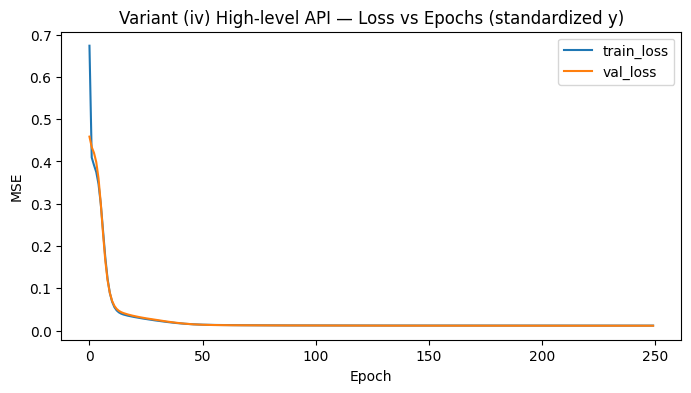

Variant (iv) TEST MSE (original y): 0.04159198902389236


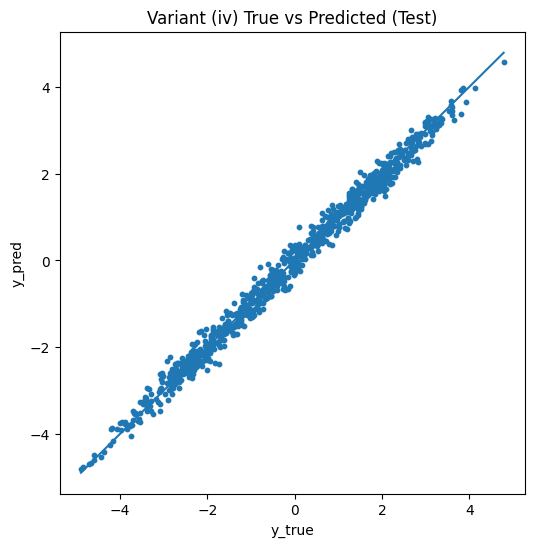

In [11]:
# This is essentially the same as (ii)/(iii), but shown with explicit callbacks for a "high-level" workflow.

model_iv = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1),
])

model_iv.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanSquaredError(name="mse")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
]

history_iv = model_iv.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=250,
    batch_size=128,
    callbacks=callbacks,
    verbose=0
)

plt.figure(figsize=(8, 4))
plt.plot(history_iv.history["loss"], label="train_loss")
plt.plot(history_iv.history["val_loss"], label="val_loss")
plt.title("Variant (iv) High-level API — Loss vs Epochs (standardized y)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

y_test_hat_s_iv = model_iv.predict(X_test_s, verbose=0)
y_test_hat_iv = y_scaler.inverse_transform(y_test_hat_s_iv)
test_mse_iv = float(np.mean((y_test_hat_iv - y_test) ** 2))
print("Variant (iv) TEST MSE (original y):", test_mse_iv)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[:, 0], y_test_hat_iv[:, 0], s=10)
plt.title("Variant (iv) True vs Predicted (Test)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
minv = min(y_test.min(), y_test_hat_iv.min())
maxv = max(y_test.max(), y_test_hat_iv.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()
